# Assignment 1: Uncertainty and Sentiment Analysis of Quarterly and Annual Financial Reports
Loughran & McDonald (2011) applied to ARK-holdings 10-K/10-Q filings, 2021–2025.

In [1]:
import pandas as pd
import numpy as np
import pytz
import math
import gzip
from collections import Counter

from src.lexicons import load_all
from src.parse import tokenize

### Load data

In [2]:
meta = pd.read_csv("data/interim/filings_meta.csv", parse_dates=["filing_date", "acceptance_datetime"])
universe = pd.read_csv("data/universe/universe.csv")
prices = pd.read_csv("data/prices/prices.csv", index_col=0, parse_dates=True)
shares = pd.read_csv("data/prices/shares.csv")

trading_days = prices.index.sort_values()
print("Loaded:", meta.shape, universe.shape, prices.shape, shares.shape)

Loaded: (1702, 14) (117, 8) (1400, 96) (3544, 5)


In [3]:
### Table 1a — company-level filters (124 ARK holdings -> 93 filers)

def clean_ticker(raw):
    t = (raw or "").strip().upper().split(" ")[0]
    if not t or "/" in t:
        return None
    if t.isdigit():
        return None
    return t

raw_holdings = pd.read_csv("data/universe/ark_holdings_raw.csv")
tickers_all = {clean_ticker(t) for t in raw_holdings["ticker"]} - {None}
n_total = len(tickers_all)

n_cik_found = len(universe)
n_no_cik = n_total - n_cik_found

is_domestic = universe["status"] == "domestic_filer"
n_domestic = int(is_domestic.sum())
n_no_filings = int((~is_domestic).sum())

n_filings_expected = int(universe.loc[is_domestic, ["n_10k", "n_10q"]].to_numpy().sum())
n_filings_downloaded = len(meta)

table1a = pd.DataFrame([
    {"step": "ARK holdings, six funds, union of unique US-listed tickers",
     "removed": 0, "remaining": n_total},
    {"step": "No CIK on SEC's ticker file (foreign private issuer, private, or delisted)",
     "removed": n_no_cik, "remaining": n_cik_found},
    {"step": "CIK found, but no 10-K/10-Q filed in the 2021-01-01 to 2025-12-31 window",
     "removed": n_no_filings, "remaining": n_domestic},
    {"step": "Filings listed by EDGAR for the kept filers",
     "removed": 0, "remaining": n_filings_expected},
    {"step": "Filings actually downloaded",
     "removed": n_filings_expected - n_filings_downloaded, "remaining": n_filings_downloaded},
])
print(table1a.to_string(index=False))

                                                                      step  removed  remaining
                ARK holdings, six funds, union of unique US-listed tickers        0        124
No CIK on SEC's ticker file (foreign private issuer, private, or delisted)        7        117
  CIK found, but no 10-K/10-Q filed in the 2021-01-01 to 2025-12-31 window       24         93
                               Filings listed by EDGAR for the kept filers        0       1702
                                               Filings actually downloaded        0       1702


### Table 1 — sample filters

In [4]:
def next_trading_day(date, trading_days):
    idx = trading_days.searchsorted(date)
    if idx >= len(trading_days):
        return pd.NaT
    return trading_days[idx]

def trading_day_offset(date, trading_days, offset):
    idx = trading_days.searchsorted(date)
    idx2 = idx + offset
    if idx2 < 0 or idx2 >= len(trading_days):
        return pd.NaT
    return trading_days[idx2]

def get_price_at_offset(row, offset):
    ticker = row['ticker']
    if ticker not in prices.columns:
        return np.nan
    d = trading_day_offset(row['day0'], trading_days, offset)
    if pd.isna(d) or d not in prices.index:
        return np.nan
    return prices.loc[d, ticker]

def has_60_days(row, offset_sign):
    ticker = row['ticker']
    if ticker not in prices.columns:
        return False
    idx = trading_days.searchsorted(row['day0'])
    series = prices[ticker]
    if offset_sign < 0:
        window = series.loc[trading_days[max(0, idx-60):idx]]
    else:
        window = series.loc[trading_days[idx:idx+61]]
    return window.notna().sum() >= 60

In [5]:
step_log = []

df = meta.copy()
step_log.append(("0. All downloaded filings (93 filers)", len(df)))

# GOOG/GOOGL share one CIK -> same accession downloaded twice under two tickers
before = len(df)
df = df.sort_values('ticker').drop_duplicates(subset='accession', keep='first')
step_log.append(("1. Dedupe same filing under dual-class ticker pair", len(df)))

df = df[df['form'].isin(['10-K', '10-Q'])]
step_log.append(("2. Drop amendments & failed parses", len(df)))

df = df[((df['form'] == '10-K') & (df['n_words'] >= 2000)) | ((df['form'] == '10-Q') & (df['n_words'] >= 1000))]
step_log.append(("3. Word count minimum (2000/1000)", len(df)))

df['quarter'] = df['filing_date'].dt.to_period('Q')
df = df.sort_values('filing_date').drop_duplicates(subset=['ticker', 'quarter'], keep='first')
step_log.append(("4. One filing per company per quarter (earliest)", len(df)))

# day0 = first trading day on/after later of (filing_date, acceptance date +1 if after 4pm ET)
eastern = pytz.timezone("US/Eastern")
df['acceptance_eastern'] = df['acceptance_datetime'].dt.tz_convert(eastern)
shift_needed = df['acceptance_eastern'].dt.time >= pd.Timestamp("16:00").time()
df['acceptance_effective_date'] = df['acceptance_eastern'].dt.normalize().dt.tz_localize(None)
df.loc[shift_needed, 'acceptance_effective_date'] += pd.Timedelta(days=1)
df['later_date'] = df[['filing_date', 'acceptance_effective_date']].max(axis=1)
df['day0'] = df['later_date'].apply(lambda d: next_trading_day(d, trading_days))
df = df[df['day0'].notna()]
step_log.append(("5a. Usable day0", len(df)))

df['price_day_minus1'] = df.apply(lambda r: get_price_at_offset(r, -1), axis=1)
df = df[df['price_day_minus1'] >= 3]
step_log.append(("5b. Price on day -1 >= $3", len(df)))

df['has_60_before'] = df.apply(lambda r: has_60_days(r, -1), axis=1)
df['has_60_after'] = df.apply(lambda r: has_60_days(r, 1), axis=1)
df = df[df['has_60_before'] & df['has_60_after']]
step_log.append(("6. 60 trading days before AND after day0", len(df)))

table1 = pd.DataFrame(step_log, columns=["Filter", "Filings remaining"])
table1["Removed"] = -table1["Filings remaining"].diff().fillna(0).astype(int)
print(table1.to_string(index=False))

final_sample = df.copy()
print("\nFinal sample:", len(final_sample), "filings")

                                            Filter  Filings remaining  Removed
             0. All downloaded filings (93 filers)               1702        0
1. Dedupe same filing under dual-class ticker pair               1682       20
                2. Drop amendments & failed parses               1682        0
                 3. Word count minimum (2000/1000)               1682        0
  4. One filing per company per quarter (earliest)               1668       14
                                   5a. Usable day0               1668        0
                         5b. Price on day -1 >= $3               1565      103
          6. 60 trading days before AND after day0               1542       23

Final sample: 1542 filings


### Table 1 diagnostic — how many filings did the acceptance-date rule move day 0 for?

In [6]:
def day0_naive(filing_date):
    idx = trading_days.searchsorted(pd.Timestamp(filing_date))
    return trading_days[idx] if idx < len(trading_days) else pd.NaT

final_sample['day0_naive'] = final_sample['filing_date'].apply(day0_naive)
moved = (final_sample['day0_naive'] != final_sample['day0']).sum()
print(f"Day 0 moved by the acceptance-date rule (vs. snapping the raw filing_date alone): "
      f"{moved} / {len(final_sample)} filings ({moved / len(final_sample):.1%})")

Day 0 moved by the acceptance-date rule (vs. snapping the raw filing_date alone): 862 / 1542 filings (55.9%)


In [7]:
### tf.idf self-check 
def _toy_check():
    docs = {
        "d1": Counter({"LOSS": 2, "RISK": 1, "GAIN": 1}),
        "d2": Counter({"LOSS": 1, "GAIN": 2}),
        "d3": Counter({"RISK": 3, "GAIN": 1}),
    }
    wordlist = {"LOSS", "RISK"}
    n_docs = len(docs)
    doc_freq = Counter()
    for c in docs.values():
        for w in wordlist:
            if c.get(w, 0) >= 1:
                doc_freq[w] += 1
    scores = []
    for c in docs.values():
        total = sum(c.values())
        distinct = len(c)
        a_j = total / distinct
        score = sum((1 + math.log(c[w])) / (1 + math.log(a_j)) * math.log(n_docs / doc_freq[w])
                     for w in wordlist if c.get(w, 0) >= 1)
        scores.append(score)
    expected = [0.8480, 0.2885, 0.5026]
    for got, exp, name in zip(scores, expected, ["d1", "d2", "d3"]):
        assert abs(got - exp) < 5e-4, f"{name}: got {got:.4f}, expected {exp}"
    print("tf.idf self-check passed:", [round(s, 4) for s in scores])

_toy_check()

tf.idf self-check passed: [0.848, 0.2885, 0.5026]


### Scoring — proportional (Fin-Neg, Fin-Unc)

In [8]:
word_lists = load_all()
neg_words = set(word_lists["Negative"])
unc_words = set(word_lists["Uncertainty"])

print(len(neg_words), "negative words;", len(unc_words), "uncertainty words")

2355 negative words; 297 uncertainty words


### Word list overlap

In [9]:
overlap = neg_words & unc_words
print(f"Negative:    {len(neg_words):4d} words")
print(f"Uncertainty: {len(unc_words):4d} words")
print(f"Overlap:     {len(overlap):4d} words "
      f"({len(overlap) / len(unc_words):.1%} of Uncertainty, {len(overlap) / len(neg_words):.1%} of Negative)")

Negative:    2355 words
Uncertainty:  297 words
Overlap:       40 words (13.5% of Uncertainty, 1.7% of Negative)


In [10]:
def score_filing(text_path):
    with gzip.open(text_path, "rt", encoding="utf-8") as fh:
        tokens = tokenize(fh.read())
    n_total = len(tokens)
    n_distinct = len(set(tokens))
    counts = Counter(tokens)
    neg_count = sum(c for w, c in counts.items() if w in neg_words)
    unc_count = sum(c for w, c in counts.items() if w in unc_words)
    return pd.Series({
        "n_total_words": n_total,
        "n_distinct_words": n_distinct,
        "neg_count": neg_count,
        "unc_count": unc_count,
        "word_counter": counts,
    })

scored = final_sample["text_path"].apply(score_filing)
final_sample = pd.concat([final_sample.reset_index(drop=True), scored.reset_index(drop=True)], axis=1)

final_sample["neg_prop"] = final_sample["neg_count"] / final_sample["n_total_words"]
final_sample["unc_prop"] = final_sample["unc_count"] / final_sample["n_total_words"]

print(final_sample[["ticker", "form", "filing_date", "neg_prop", "unc_prop"]].head(10))
print("\nProportional summary:")
print(final_sample[["neg_prop", "unc_prop"]].describe())

  ticker  form filing_date  neg_prop  unc_prop
0    LMT  10-K  2021-01-28  0.016740  0.019533
1   NFLX  10-K  2021-01-28  0.024809  0.023647
2   META  10-K  2021-01-28  0.028838  0.021822
3    AMD  10-K  2021-01-29  0.024190  0.019883
4   GOOG  10-K  2021-02-03  0.025304  0.021430
5   AMZN  10-K  2021-02-03  0.021396  0.018426
6    ICE  10-K  2021-02-04  0.020512  0.019486
7   PYPL  10-K  2021-02-05  0.027275  0.020805
8   PINS  10-K  2021-02-05  0.024766  0.023209
9   TSLA  10-K  2021-02-08  0.018196  0.017255

Proportional summary:
          neg_prop     unc_prop
count  1542.000000  1542.000000
mean      0.022655     0.019779
std       0.009741     0.005928
min       0.003654     0.006303
25%       0.013259     0.014839
50%       0.022980     0.019687
75%       0.031782     0.024912
max       0.050438     0.035802


### Scoring — tf.idf (equation 1)

In [11]:
N = len(final_sample)

neg_df = Counter()
unc_df = Counter()
for counts in final_sample["word_counter"]:
    words_in_doc = set(counts.keys())
    for w in words_in_doc & neg_words:
        neg_df[w] += 1
    for w in words_in_doc & unc_words:
        unc_df[w] += 1

def tfidf_for_row(counts, wordlist, df_counts, N):
    n_total = sum(counts.values())
    n_distinct = len(counts)
    if n_distinct == 0:
        return 0.0
    a_j = n_total / n_distinct
    score = 0.0
    for w in wordlist:
        tf = counts.get(w, 0)
        if tf >= 1:
            idf = math.log(N / df_counts[w])
            score += (1 + math.log(tf)) / (1 + math.log(a_j)) * idf
    return score

final_sample["neg_tfidf"] = final_sample["word_counter"].apply(lambda c: tfidf_for_row(c, neg_words, neg_df, N))
final_sample["unc_tfidf"] = final_sample["word_counter"].apply(lambda c: tfidf_for_row(c, unc_words, unc_df, N))

print(final_sample[["ticker", "form", "filing_date", "neg_prop", "neg_tfidf", "unc_prop", "unc_tfidf"]].head(10))
print("\ntf.idf summary:")
print(final_sample[["neg_tfidf", "unc_tfidf"]].describe())
print("\ncorrelation neg_prop vs neg_tfidf:", final_sample["neg_prop"].corr(final_sample["neg_tfidf"]))
print("correlation unc_prop vs unc_tfidf:", final_sample["unc_prop"].corr(final_sample["unc_tfidf"]))

  ticker  form filing_date  neg_prop   neg_tfidf  unc_prop  unc_tfidf
0    LMT  10-K  2021-01-28  0.016740   98.918046  0.019533  31.143178
1   NFLX  10-K  2021-01-28  0.024809  101.391300  0.023647  14.817465
2   META  10-K  2021-01-28  0.028838  139.454548  0.021822  28.766827
3    AMD  10-K  2021-01-29  0.024190  106.887920  0.019883  20.339953
4   GOOG  10-K  2021-02-03  0.025304  117.716506  0.021430  24.915097
5   AMZN  10-K  2021-02-03  0.021396   71.298412  0.018426  15.421942
6    ICE  10-K  2021-02-04  0.020512  163.179813  0.019486  30.594085
7   PYPL  10-K  2021-02-05  0.027275  124.648278  0.020805  19.492517
8   PINS  10-K  2021-02-05  0.024766  130.612450  0.023209  23.788279
9   TSLA  10-K  2021-02-08  0.018196  115.517241  0.017255  23.196751

tf.idf summary:
         neg_tfidf    unc_tfidf
count  1542.000000  1542.000000
mean     98.602111    16.397230
std      80.526891    11.008085
min       2.141048     1.340688
25%      19.403456     6.969397
50%      96.189402   

### Q2 — correlation between sentiment and uncertainty, and a divergent filing

In [12]:
corr_prop = final_sample["neg_prop"].corr(final_sample["unc_prop"])
corr_tfidf = final_sample["neg_tfidf"].corr(final_sample["unc_tfidf"])
print(f"Correlation (proportional): {corr_prop:.3f}")
print(f"Correlation (tf.idf):       {corr_tfidf:.3f}")

# A filing that scores high on one measure, low on the other (by rank gap) — for Q2's
# "find a filing" instruction. Read its text_path yourself to describe what it looks like.
final_sample["neg_rank"] = final_sample["neg_prop"].rank(pct=True)
final_sample["unc_rank"] = final_sample["unc_prop"].rank(pct=True)
final_sample["rank_gap"] = final_sample["neg_rank"] - final_sample["unc_rank"]
divergent = final_sample.reindex(final_sample["rank_gap"].abs().sort_values(ascending=False).index)
divergent[["ticker", "form", "filing_date", "neg_prop", "unc_prop", "neg_rank", "unc_rank", "text_path"]].head(5)

Correlation (proportional): 0.887
Correlation (tf.idf):       0.934


,ticker,form,filing_date,neg_prop,unc_prop,neg_rank,unc_rank,text_path
483,DKNG,10-Q,2022-08-05,0.039694,0.015942,0.986381,0.317769,data\interim\text\000188368522000026.txt.gz
1187,DKNG,10-Q,2024-11-08,0.050438,0.016389,1.000000,0.339170,data\interim\text\000188368524000036.txt.gz
566,DKNG,10-Q,2022-11-04,0.043156,0.016410,0.996109,0.342088,data\interim\text\000188368522000036.txt.gz
1084,DKNG,10-Q,2024-08-02,0.047200,0.017295,0.998054,0.389105,data\interim\text\000188368524000032.txt.gz
786,DKNG,10-Q,2023-08-04,0.045129,0.017648,0.996757,0.402724,data\interim\text\000188368523000037.txt.gz


### Table 2 — summary statistics, 10-K vs 10-Q

In [13]:
table2 = final_sample.groupby("form")[["neg_prop", "neg_tfidf", "unc_prop", "unc_tfidf"]].describe().T
print(table2)
table2.to_csv("outputs/table2_summary_stats.csv")

form                   10-K         10-Q
neg_prop  count  384.000000  1158.000000
          mean     0.025471     0.021721
          std      0.004508     0.010777
          min      0.012768     0.003654
          25%      0.022601     0.012218
          50%      0.025761     0.017733
          75%      0.028682     0.033165
          max      0.036260     0.050438
neg_tfidf count  384.000000  1158.000000
          mean   167.193998    75.856615
          std     61.293299    72.895991
          min     59.554148     2.141048
          25%    119.804169    16.302345
          50%    152.975637    34.423794
          75%    205.369148   133.984163
          max    345.885178   284.362298
unc_prop  count  384.000000  1158.000000
          mean     0.021133     0.019330
          std      0.002628     0.006611
          min      0.014154     0.006303
          25%      0.019415     0.013885
          50%      0.021365     0.017624
          75%      0.022975     0.026089
          max   

### Table 3 — 30 most common words per list, with each word's share

In [14]:
neg_total_count = Counter()
unc_total_count = Counter()
for counts in final_sample["word_counter"]:
    for w in counts:
        if w in neg_words:
            neg_total_count[w] += counts[w]
        if w in unc_words:
            unc_total_count[w] += counts[w]

def top_words_table(total_count, df_counts, N, n=30):
    total = sum(total_count.values())
    top = total_count.most_common(n)
    rows = []
    for w, c in top:
        d = df_counts[w]
        rows.append({
            "word": w, "count": c, "share_of_list_total": c / total,
            "df": d, "pct_of_filings": d / N,
            "idf": math.log(N / d) if d else np.nan,
        })
    return pd.DataFrame(rows)

table3_negative = top_words_table(neg_total_count, neg_df, N)
table3_uncertainty = top_words_table(unc_total_count, unc_df, N)

print("Table 3 — Negative list, 30 most frequent words")
print(table3_negative.to_string(index=False))
print("\nTable 3 — Uncertainty list, 30 most frequent words")
print(table3_uncertainty.to_string(index=False))

print(f"\nTop 10 share of Negative total: {table3_negative['share_of_list_total'].head(10).sum():.1%}")
print(f"Top 10 share of Uncertainty total: {table3_uncertainty['share_of_list_total'].head(10).sum():.1%}")

Table 3 — Negative list, 30 most frequent words
          word  count  share_of_list_total   df  pct_of_filings      idf
          LOSS  57793             0.047512 1542        1.000000 0.000000
     ADVERSELY  57066             0.046915 1439        0.933204 0.069132
       ADVERSE  35207             0.028944 1411        0.915045 0.088782
        CLAIMS  32908             0.027054 1286        0.833982 0.181544
          HARM  26192             0.021533 1079        0.699741 0.357046
       AGAINST  26019             0.021390 1338        0.867704 0.141904
        UNABLE  25990             0.021367 1233        0.799611 0.223630
       FAILURE  24699             0.020305 1195        0.774968 0.254934
        LOSSES  23712             0.019494 1497        0.970817 0.029617
    LITIGATION  22980             0.018892 1394        0.904021 0.100903
          FAIL  18409             0.015134 1039        0.673800 0.394822
    NEGATIVELY  15976             0.013134 1231        0.798314 0.225253
   

### Quarterly series + VIX (for Figure 1 and Table 4)

In [15]:
final_sample['quarter_ts'] = final_sample['quarter'].dt.to_timestamp()

quarterly = (
    final_sample.groupby(['quarter', 'form'])[['neg_prop', 'unc_prop', 'neg_tfidf', 'unc_tfidf']]
    .mean()
    .reset_index()
)
quarterly_n = final_sample.groupby(['quarter', 'form']).size().rename('n_filings').reset_index()
quarterly = quarterly.merge(quarterly_n, on=['quarter', 'form'])
quarterly['quarter_ts'] = quarterly['quarter'].dt.to_timestamp()

# a single-filing quarter isn't a meaningful average - drop it
MIN_QUARTER_N = 2
thin = quarterly[quarterly['n_filings'] < MIN_QUARTER_N]
if len(thin):
    print(f"Dropping {len(thin)} (quarter, form) cell(s) built from fewer than {MIN_QUARTER_N} filing(s):")
    print(thin[['quarter', 'form', 'n_filings']].to_string(index=False))
quarterly = quarterly[quarterly['n_filings'] >= MIN_QUARTER_N].reset_index(drop=True)

vix = prices['^VIX'].dropna()
vix_q = vix.resample('QS').mean()
vix_q.index = vix_q.index.to_period('Q')
vix_q = vix_q[(vix_q.index >= quarterly['quarter'].min()) & (vix_q.index <= quarterly['quarter'].max())]

print(quarterly.head(10))
print("\nVIX quarterly (first 5):")
print(vix_q.head())

Dropping 1 (quarter, form) cell(s) built from fewer than 2 filing(s):
quarter form  n_filings
 2021Q2 10-K          1
  quarter  form  neg_prop  unc_prop   neg_tfidf  unc_tfidf  n_filings  \
0  2021Q1  10-K  0.023161  0.019953  154.195028  26.957267         57   
1  2021Q1  10-Q  0.022857  0.019986   59.850713  10.481438          8   
2  2021Q2  10-Q  0.020181  0.019242   68.325913  12.406101         67   
3  2021Q3  10-K  0.021747  0.019068  100.817657  17.911952          2   
4  2021Q3  10-Q  0.021617  0.019317   78.068896  13.515594         72   
5  2021Q4  10-K  0.021970  0.019266  113.528050  18.918971          6   
6  2021Q4  10-Q  0.022464  0.019705   84.374393  14.526357         71   
7  2022Q1  10-K  0.025154  0.021015  174.822476  30.208283         68   
8  2022Q1  10-Q  0.023466  0.020012   60.966611  10.232589          8   
9  2022Q2  10-K  0.024523  0.021236  134.758461  24.740245          4   

  quarter_ts  
0 2021-01-01  
1 2021-01-01  
2 2021-04-01  
3 2021-07-01  
4 2

### Figure 1 — quarterly tone by form, with VIX overlay

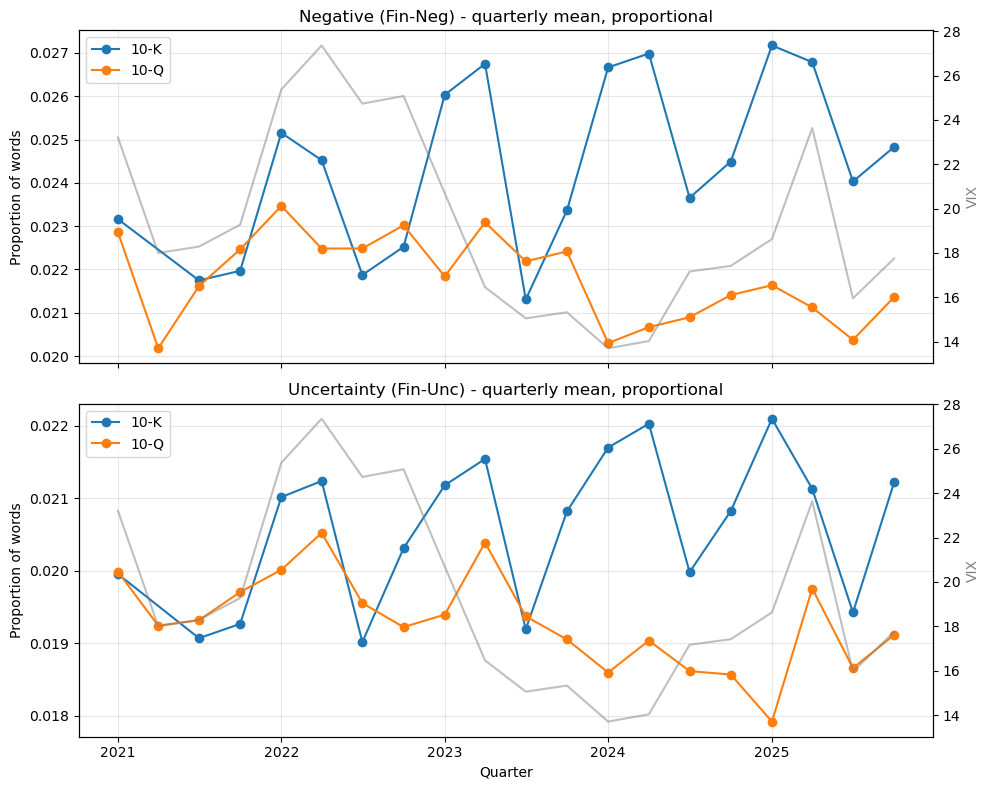

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for ax, measure, title in zip(axes, ['neg_prop', 'unc_prop'], ['Negative (Fin-Neg)', 'Uncertainty (Fin-Unc)']):
    ax_vix = ax.twinx()
    ax_vix.plot(vix_q.index.to_timestamp(), vix_q.values, color='gray', lw=1.5, alpha=0.5, label='VIX')
    ax_vix.set_ylabel('VIX', color='gray')

    for form, color in [('10-K', 'tab:blue'), ('10-Q', 'tab:orange')]:
        sub = quarterly[quarterly['form'] == form].sort_values('quarter_ts')
        ax.plot(sub['quarter_ts'], sub[measure], marker='o', label=form, color=color)

    ax.set_title(f'{title} - quarterly mean, proportional')
    ax.set_ylabel('Proportion of words')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Quarter')
plt.tight_layout()
plt.savefig('outputs/figure1_trends.png', dpi=150, bbox_inches='tight')
plt.show()

### Table 4 — trend tests (aggregate, Newey-West + within-firm)

In [17]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

def aggregate_trend_test(series_by_quarter, maxlags=4):
    y = series_by_quarter.sort_index()
    t = np.arange(len(y))
    X = sm.add_constant(t)
    ols = sm.OLS(y.values, X).fit()
    hac = sm.OLS(y.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return pd.Series({
        "n_obs": len(y), "slope_per_year": ols.params[1] * 4,
        "t_ols": ols.tvalues[1], "p_ols": ols.pvalues[1],
        "t_hac": hac.tvalues[1], "p_hac": hac.pvalues[1],
    })

def within_firm_trend_test(df, measure, form):
    sub = df[df['form'] == form].copy()
    firm_q = sub.groupby(['ticker', 'quarter'])[measure].mean().reset_index()
    firm_q['quarter_idx'] = firm_q['quarter'].apply(lambda p: p.ordinal)
    firm_q['demeaned'] = firm_q.groupby('ticker')[measure].transform(lambda s: s - s.mean())
    firm_q['t_demeaned'] = firm_q.groupby('ticker')['quarter_idx'].transform(lambda s: s - s.mean())
    model = smf.ols("demeaned ~ t_demeaned - 1", data=firm_q).fit(
        cov_type="cluster", cov_kwds={"groups": firm_q['ticker']}
    )
    return pd.Series({
        "n_obs": len(firm_q), "n_firms": firm_q['ticker'].nunique(),
        "slope_per_year": model.params['t_demeaned'] * 4,
        "t": model.tvalues['t_demeaned'], "p": model.pvalues['t_demeaned'],
    })

# NOTE: aggregate rows now carry t_ols/p_ols/t_hac/p_hac; within_firm rows carry t/p.
# This is intentional -- Table 4 in the report needs BOTH the raw OLS t and the
# Newey-West/HAC-corrected t for the aggregate test, to show what the correction
# actually does to significance.
table4_rows = {}
for measure in ['neg_prop', 'unc_prop', 'neg_tfidf', 'unc_tfidf']:
    for form in ['10-K', '10-Q']:
        agg_series = quarterly[quarterly['form'] == form].set_index('quarter')[measure]
        table4_rows[(measure, form, 'aggregate')] = aggregate_trend_test(agg_series)
        table4_rows[(measure, form, 'within_firm')] = within_firm_trend_test(final_sample, measure, form)

table4 = pd.DataFrame(table4_rows).T
table4.index.names = ['measure', 'form', 'test']
print(table4.round(4).to_string())
table4.to_csv("outputs/table4_trend_tests.csv")


                            n_firms   n_obs       p   p_hac   p_ols  slope_per_year       t   t_hac   t_ols
measure   form test                                                                                        
neg_prop  10-K aggregate        NaN    19.0     NaN  0.0000  0.0341          0.0007     NaN  4.9172  2.3047
               within_firm     88.0   384.0  0.0000     NaN     NaN          0.0008  9.4092     NaN     NaN
          10-Q aggregate        NaN    20.0     NaN  0.0155  0.0355         -0.0003     NaN -2.4213 -2.2733
               within_firm     90.0  1158.0  0.0489     NaN     NaN         -0.0004 -1.9691     NaN     NaN
unc_prop  10-K aggregate        NaN    19.0     NaN  0.0070  0.0942          0.0003     NaN  2.6967  1.7728
               within_firm     88.0   384.0  0.0000     NaN     NaN          0.0004  6.6226     NaN     NaN
          10-Q aggregate        NaN    20.0     NaN  0.0002  0.0074         -0.0003     NaN -3.7648 -3.0156
               within_firm  

### Check — is the tf.idf trend a document-length artifact?

In [18]:
print("Correlation with document length (n_total_words):")
for c in ['neg_prop', 'unc_prop', 'neg_tfidf', 'unc_tfidf']:
    print(f"  {c:12s} {final_sample[c].corr(final_sample['n_total_words']):+.3f}")

for form in ['10-K', '10-Q']:
    r = within_firm_trend_test(final_sample, 'n_total_words', form)
    print(f"\n{form} word count trend: {r['slope_per_year']:+.1f} words/year, t={r['t']:+.2f}, p={r['p']:.4f}")

Correlation with document length (n_total_words):
  neg_prop     +0.636
  unc_prop     +0.594
  neg_tfidf    +0.956
  unc_tfidf    +0.954

10-K word count trend: -514.7 words/year, t=-1.80, p=0.0723

10-Q word count trend: -545.4 words/year, t=-2.27, p=0.0229


### Event-study variables — filing-period excess return, pre/post volatility

In [19]:
final_sample['filing_return'] = final_sample.apply(
    lambda r: (get_price_at_offset(r, 3) / r['price_day_minus1'] - 1) if pd.notna(r['price_day_minus1']) else np.nan,
    axis=1
)
final_sample['bench_price_minus1'] = final_sample.apply(lambda r: get_price_at_offset({'ticker': 'SPY', 'day0': r['day0']}, -1), axis=1)
final_sample['bench_price_end'] = final_sample.apply(lambda r: get_price_at_offset({'ticker': 'SPY', 'day0': r['day0']}, 3), axis=1)
final_sample['bench_return'] = final_sample['bench_price_end'] / final_sample['bench_price_minus1'] - 1
final_sample['excess_return'] = final_sample['filing_return'] - final_sample['bench_return']

def realized_vol(row, offset_start, offset_end):
    ticker = row['ticker']
    if ticker not in prices.columns:
        return np.nan
    idx = trading_days.searchsorted(row['day0'])
    lo, hi = idx + offset_start, idx + offset_end
    if lo < 0 or hi >= len(trading_days):
        return np.nan
    window_dates = trading_days[lo:hi+1]
    rets = prices[ticker].reindex(window_dates).pct_change().dropna()
    if len(rets) < 10:
        return np.nan
    return rets.std() * np.sqrt(252)

final_sample['vol_pre'] = final_sample.apply(lambda r: realized_vol(r, -60, -6), axis=1)
final_sample['vol_post'] = final_sample.apply(lambda r: realized_vol(r, 4, 63), axis=1)

final_sample = final_sample.merge(shares[['accession', 'shares_outstanding']], on='accession', how='left')
final_sample['log_size'] = np.log(final_sample['price_day_minus1'] * final_sample['shares_outstanding'])
final_sample['is_10k'] = (final_sample['form'] == '10-K').astype(int)

print(final_sample[['ticker', 'filing_date', 'excess_return', 'vol_pre', 'vol_post', 'log_size']].describe())
print("\nmissing counts:")
print(final_sample[['excess_return', 'vol_pre', 'vol_post', 'log_size', 'shares_outstanding']].isna().sum())

                         filing_date  excess_return      vol_pre     vol_post  \
count                           1542    1542.000000  1542.000000  1542.000000   
mean   2023-07-20 08:00:56.031128064      -0.003500     0.540669     0.539754   
min              2021-01-28 00:00:00      -0.488497     0.011526     0.023347   
25%              2022-05-04 00:00:00      -0.062472     0.314092     0.330360   
50%              2023-08-02 00:00:00      -0.007970     0.481960     0.500170   
75%              2024-10-31 00:00:00       0.040980     0.693220     0.701264   
max              2025-12-22 00:00:00       0.784861     6.454694     3.013396   
std                              NaN       0.114618     0.342512     0.280681   

          log_size  
count  1497.000000  
mean     23.357137  
min      15.919376  
25%      21.832012  
50%      23.484952  
75%      24.859896  
max      29.139888  
std       2.098355  

missing counts:
excess_return          0
vol_pre                0
vol_post      

### Additional controls — dollar volume, pre-filing momentum, quarter string

In [20]:
volume = pd.read_csv("data/prices/volume.csv", index_col=0, parse_dates=True)

def get_volume_at_offset(row, offset):
    ticker = row['ticker']
    if ticker not in volume.columns:
        return np.nan
    d = trading_day_offset(row['day0'], trading_days, offset)
    if pd.isna(d) or d not in volume.index:
        return np.nan
    return volume.loc[d, ticker]

final_sample['volume_minus1'] = final_sample.apply(lambda r: get_volume_at_offset(r, -1), axis=1)
final_sample['dollar_volume'] = final_sample['price_day_minus1'] * final_sample['volume_minus1']
final_sample['log_dollar_volume'] = np.log(final_sample['dollar_volume'])

final_sample['pre_exret'] = final_sample.apply(
    lambda r: (get_price_at_offset(r, -6) / get_price_at_offset(r, -60) - 1)
    if pd.notna(get_price_at_offset(r, -60)) and get_price_at_offset(r, -60) != 0 else np.nan,
    axis=1
)

final_sample['quarter_str'] = final_sample['quarter'].astype(str)

def finite_subset(df, cols):
    mask = np.isfinite(df[cols].to_numpy(dtype=float)).all(axis=1)
    return df.loc[mask].copy()

print(final_sample[['log_dollar_volume', 'pre_exret']].describe())

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


       log_dollar_volume    pre_exret
count        1542.000000  1542.000000
mean                -inf     0.042092
std                  NaN     0.291845
min                 -inf    -0.843199
25%            17.480298    -0.132747
50%            19.348476     0.015792
75%            20.926047     0.154421
max            24.879431     2.923190


### Table 5 — post-filing volatility on uncertainty, with/without pre-filing vol control

In [21]:
BETWEEN_CONTROLS = "log_size + log_dollar_volume + pre_exret + is_10k + C(quarter_str)"
WITHIN_CONTROLS  = "log_size + log_dollar_volume + pre_exret + is_10k + C(ticker) + C(quarter_str)"

table5_rows = {}
for label, xvar in [('prop', 'unc_prop'), ('tfidf', 'unc_tfidf')]:
    base_cols = [xvar, 'vol_post', 'vol_pre', 'log_size', 'log_dollar_volume', 'pre_exret']
    d = finite_subset(final_sample, base_cols)
    for spec_name, controls in [('between_firm', BETWEEN_CONTROLS), ('within_firm', WITHIN_CONTROLS)]:
        for ctrl_label, extra in [('without_pre_vol', ''), ('with_pre_vol', ' + vol_pre')]:
            m = smf.ols(f"vol_post ~ {xvar}{extra} + {controls}", data=d).fit(
                cov_type="cluster", cov_kwds={"groups": d['ticker']}
            )
            table5_rows[f"{label} / {spec_name} / {ctrl_label}"] = {
                "n": m.nobs, "coef": m.params[xvar], "se": m.bse[xvar],
                "t": m.tvalues[xvar], "p": m.pvalues[xvar],
                "effect_1sd": m.params[xvar] * d[xvar].std(),
            }

table5_pooled = pd.DataFrame(table5_rows).T
print("Table 5 -- pooled across forms, is_10k as a control:")
print(table5_pooled.round(4))
table5_pooled.to_csv("outputs/table5_pooled.csv")

# Table 5b -- the same four specs, run separately within each form.
# The assignment's REPORT.md template (Q5) asks for Table 5 by form, not just
# pooled with an is_10k dummy -- a dummy only shifts the intercept, it doesn't
# let the *slope* on uncertainty differ by form the way a true split does.
# is_10k is dropped from the controls here since it's constant within a form.
FORM_BETWEEN_CONTROLS = "log_size + log_dollar_volume + pre_exret + C(quarter_str)"
FORM_WITHIN_CONTROLS  = "log_size + log_dollar_volume + pre_exret + C(ticker) + C(quarter_str)"

table5_form_rows = {}
for form in ['10-K', '10-Q']:
    sub = final_sample[final_sample['form'] == form]
    for label, xvar in [('prop', 'unc_prop'), ('tfidf', 'unc_tfidf')]:
        base_cols = [xvar, 'vol_post', 'vol_pre', 'log_size', 'log_dollar_volume', 'pre_exret']
        d = finite_subset(sub, base_cols)
        for spec_name, controls in [('between_firm', FORM_BETWEEN_CONTROLS), ('within_firm', FORM_WITHIN_CONTROLS)]:
            for ctrl_label, extra in [('without_pre_vol', ''), ('with_pre_vol', ' + vol_pre')]:
                n_firms = d['ticker'].nunique()
                if spec_name == 'within_firm' and n_firms < 5:
                    print(f"skipped {form}/{label}/{spec_name}/{ctrl_label}: only {n_firms} firms, too few for firm FE + clustering")
                    continue
                try:
                    m = smf.ols(f"vol_post ~ {xvar}{extra} + {controls}", data=d).fit(
                        cov_type="cluster", cov_kwds={"groups": d['ticker']}
                    )
                except Exception as e:
                    print(f"skipped {form}/{label}/{spec_name}/{ctrl_label}: {e}")
                    continue
                table5_form_rows[f"{form} / {label} / {spec_name} / {ctrl_label}"] = {
                    "n": m.nobs, "n_firms": n_firms, "coef": m.params[xvar], "se": m.bse[xvar],
                    "t": m.tvalues[xvar], "p": m.pvalues[xvar],
                    "effect_1sd": m.params[xvar] * d[xvar].std(),
                }

table5_by_form = pd.DataFrame(table5_form_rows).T
print("\nTable 5b -- split by form:")
print(table5_by_form.round(4))
table5_by_form.to_csv("outputs/table5_by_form.csv")


Table 5 -- pooled across forms, is_10k as a control:
                                             n    coef      se       t  \
prop / between_firm / without_pre_vol   1495.0  8.3304  2.0441  4.0753   
prop / between_firm / with_pre_vol      1495.0  5.8262  1.6361  3.5610   
prop / within_firm / without_pre_vol    1495.0 -1.5172  1.2274 -1.2360   
prop / within_firm / with_pre_vol       1495.0 -1.5554  1.2001 -1.2961   
tfidf / between_firm / without_pre_vol  1495.0  0.0058  0.0014  4.1515   
tfidf / between_firm / with_pre_vol     1495.0  0.0041  0.0011  3.6236   
tfidf / within_firm / without_pre_vol   1495.0 -0.0001  0.0009 -0.1386   
tfidf / within_firm / with_pre_vol      1495.0 -0.0001  0.0009 -0.1014   

                                             p  effect_1sd  
prop / between_firm / without_pre_vol   0.0000      0.0495  
prop / between_firm / with_pre_vol      0.0004      0.0346  
prop / within_firm / without_pre_vol    0.2164     -0.0090  
prop / within_firm / with_pre_vol   

### Table 6 — filing-period return on sentiment, with controls

In [22]:
table6_rows = {}
for spec_name, controls in [('quarter_fe_only', BETWEEN_CONTROLS), ('firm_and_quarter_fe', WITHIN_CONTROLS)]:
    for label, xvar in [('prop', 'neg_prop'), ('tfidf', 'neg_tfidf')]:
        base_cols = [xvar, 'excess_return', 'vol_pre', 'log_size', 'log_dollar_volume', 'pre_exret']
        d = finite_subset(final_sample, base_cols)
        m = smf.ols(f"excess_return ~ {xvar} + vol_pre + {controls}", data=d).fit(
            cov_type="cluster", cov_kwds={"groups": d['ticker']}
        )
        table6_rows[f"{label} / {spec_name}"] = {
            "n": m.nobs, "coef": m.params[xvar], "se": m.bse[xvar],
            "t": m.tvalues[xvar], "p": m.pvalues[xvar],
            "effect_1sd_pp": m.params[xvar] * d[xvar].std() * 100,
        }

table6 = pd.DataFrame(table6_rows).T
print(table6.round(5))
print(f"\nSD of the 4-day excess return: {final_sample['excess_return'].std()*100:.2f} pp")

                                  n     coef       se        t        p  \
prop / quarter_fe_only       1495.0 -0.56858  0.28814 -1.97327  0.04846   
tfidf / quarter_fe_only      1495.0 -0.00009  0.00004 -2.06755  0.03868   
prop / firm_and_quarter_fe   1495.0 -1.14233  0.59225 -1.92880  0.05376   
tfidf / firm_and_quarter_fe  1495.0 -0.00014  0.00010 -1.40996  0.15855   

                             effect_1sd_pp  
prop / quarter_fe_only            -0.55559  
tfidf / quarter_fe_only           -0.72029  
prop / firm_and_quarter_fe        -1.11624  
tfidf / firm_and_quarter_fe       -1.09795  

SD of the 4-day excess return: 11.46 pp


### Power check for Table 6

In [23]:
def power_check(m, xvar, d):
    se = m.bse[xvar]
    sd = d[xvar].std()
    mde = 2.8 * se  # (z_.975 + z_.80) ~ 2.8 at 80% power, alpha=.05 two-sided
    observed = m.params[xvar]
    return {
        "n": m.nobs, "se_clustered": se, "observed_coef": observed, "mde": mde,
        "observed_1sd_pp": observed * sd * 100, "mde_1sd_pp": mde * sd * 100,
        "powered_for_observed_effect": "yes" if abs(observed) >= mde else "NO",
    }

power_rows = {}
for spec_name, controls in [('quarter_fe_only', BETWEEN_CONTROLS), ('firm_and_quarter_fe', WITHIN_CONTROLS)]:
    xvar = 'neg_prop'
    base_cols = [xvar, 'excess_return', 'vol_pre', 'log_size', 'log_dollar_volume', 'pre_exret']
    d = finite_subset(final_sample, base_cols)
    m = smf.ols(f"excess_return ~ {xvar} + vol_pre + {controls}", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d['ticker']}
    )
    power_rows[spec_name] = power_check(m, xvar, d)

power_table = pd.DataFrame(power_rows).T
print(power_table.round(5))
print(f"\nSD of the 4-day excess return: {final_sample['excess_return'].std()*100:.2f} pp")
print("Compare 'mde_1sd_pp' to that to judge whether the test had a real chance.")

                          n se_clustered observed_coef       mde  \
quarter_fe_only      1495.0      0.28814     -0.568578  0.806792   
firm_and_quarter_fe  1495.0     0.592248      -1.14233  1.658293   

                    observed_1sd_pp mde_1sd_pp powered_for_observed_effect  
quarter_fe_only           -0.555591   0.788364                          NO  
firm_and_quarter_fe       -1.116238   1.620417                          NO  

SD of the 4-day excess return: 11.46 pp
Compare 'mde_1sd_pp' to that to judge whether the test had a real chance.
